# Adaptive K-Selection Analysis for Neural Feature Description
## Bachelor Thesis - Mechanistic Interpretability

This notebook analyzes:
1. **Adaptive K-Selection**: Comparing davies_bouldin, bic, silhouette vs fixed k=5
2. **Description Quality**: Evaluating generated descriptions via AUC and MAD scores
3. **Method Comparison**: Statistical analysis across 60 neurons

## Setup

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Paths
DESC_DIR = Path('descriptions/gemini-2-5-flash/gpt2-xl')
RESULTS_DIR = Path('results')

print("✓ Setup complete")

✓ Setup complete


## Part 1: Adaptive K-Selection Analysis

Analyze how many clusters each method selected for each neuron.

In [70]:
# Load all description files and extract k values
import csv
import re

def extract_method_from_filename(filename):
    """Extract method from filename: gpt2-xl_layer-X_unit-Y_METHOD_timestamp.csv"""
    match = re.search(r'unit-\d+_(.+?)_\d{4}-\d{2}-\d{2}', filename)
    return match.group(1) if match else 'unknown'

# Collect k values per neuron per method
k_data = []

for csv_file in DESC_DIR.glob('*.csv'):
    # Extract metadata from filename
    match = re.search(r'layer-(\d+)_unit-(\d+)', csv_file.name)
    if not match:
        continue
    
    layer = int(match.group(1))
    unit = int(match.group(2))
    method = extract_method_from_filename(csv_file.name)
    
    # Count descriptions (k value)
    with open(csv_file, 'r') as f:
        reader = csv.reader(f)
        k = len(list(reader)) - 1  # -1 for header
    
    k_data.append({
        'layer': layer,
        'unit': unit,
        'method': method,
        'k': k
    })

k_df = pd.DataFrame(k_data)

print(f"Total files analyzed: {len(k_df)}")
print(f"Unique neurons: {k_df[['layer', 'unit']].drop_duplicates().shape[0]}")
print(f"\nMethods found: {sorted(k_df['method'].unique())}")
k_df.head(10)

Total files analyzed: 240
Unique neurons: 60

Methods found: ['bic', 'davies_bouldin', 'fixed-k5', 'silhouette']


,layer,unit,method,k
0,40,4055,silhouette,10
1,20,1004,silhouette,8
2,20,2325,fixed-k5,5
3,40,183,silhouette,2
4,0,4297,fixed-k5,5
5,40,6106,silhouette,2
6,20,5741,davies_bouldin,10
7,0,1149,davies_bouldin,10
8,20,5278,davies_bouldin,10
9,20,4683,fixed-k5,5


In [71]:
# Summary statistics: K values by method
print("="*80)
print("K-VALUE STATISTICS BY METHOD")
print("="*80)

k_stats = k_df.groupby('method')['k'].describe()
print(k_stats)

print("\n" + "="*80)
print("AVERAGE K BY METHOD")
print("="*80)
mean_k = k_df.groupby('method')['k'].mean().sort_values(ascending=False)
for method, k in mean_k.items():
    print(f"{method:20s}: {k:.2f}")

K-VALUE STATISTICS BY METHOD
                count      mean       std  min   25%   50%    75%   max
method                                                                 
bic              60.0  2.000000  0.000000  2.0   2.0   2.0   2.00   2.0
davies_bouldin   60.0  9.766667  0.464563  8.0  10.0  10.0  10.00  10.0
fixed-k5         60.0  5.000000  0.000000  5.0   5.0   5.0   5.00   5.0
silhouette       60.0  5.766667  3.697762  2.0   2.0   7.0   9.25  10.0

AVERAGE K BY METHOD
davies_bouldin      : 9.77
silhouette          : 5.77
fixed-k5            : 5.00
bic                 : 2.00


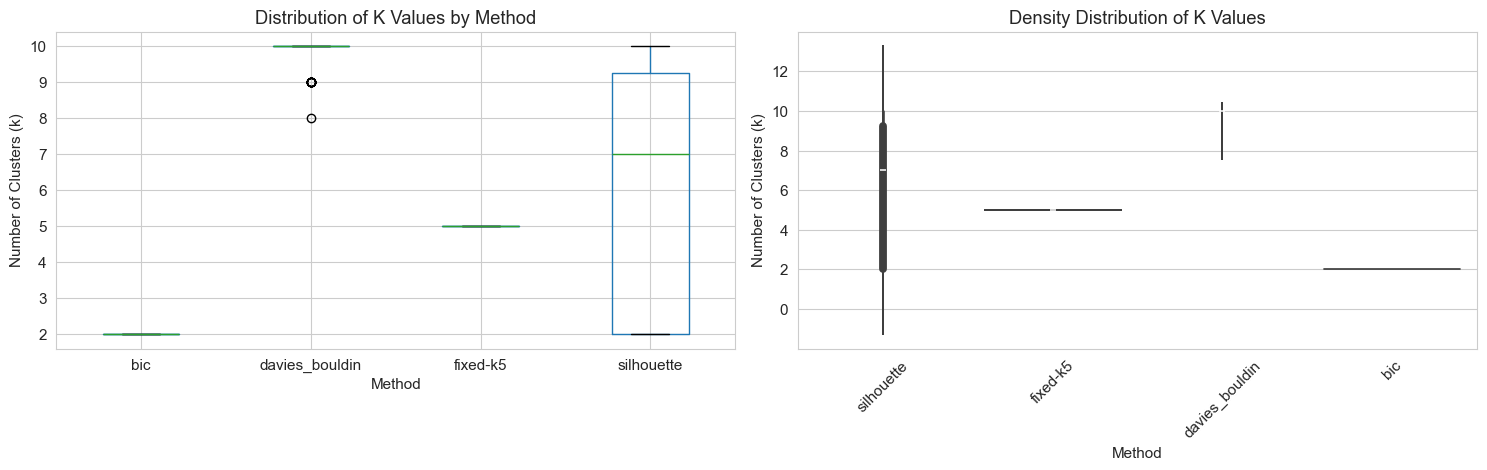

✓ Saved: analysis_k_distribution.png


In [72]:
# Visualization 1: Distribution of K values by method
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Box plot
k_df.boxplot(column='k', by='method', ax=axes[0])
axes[0].set_title('Distribution of K Values by Method')
axes[0].set_xlabel('Method')
axes[0].set_ylabel('Number of Clusters (k)')
axes[0].get_figure().suptitle('')  # Remove default title

# Violin plot
sns.violinplot(data=k_df, x='method', y='k', ax=axes[1])
axes[1].set_title('Density Distribution of K Values')
axes[1].set_xlabel('Method')
axes[1].set_ylabel('Number of Clusters (k)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('analysis_k_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: analysis_k_distribution.png")

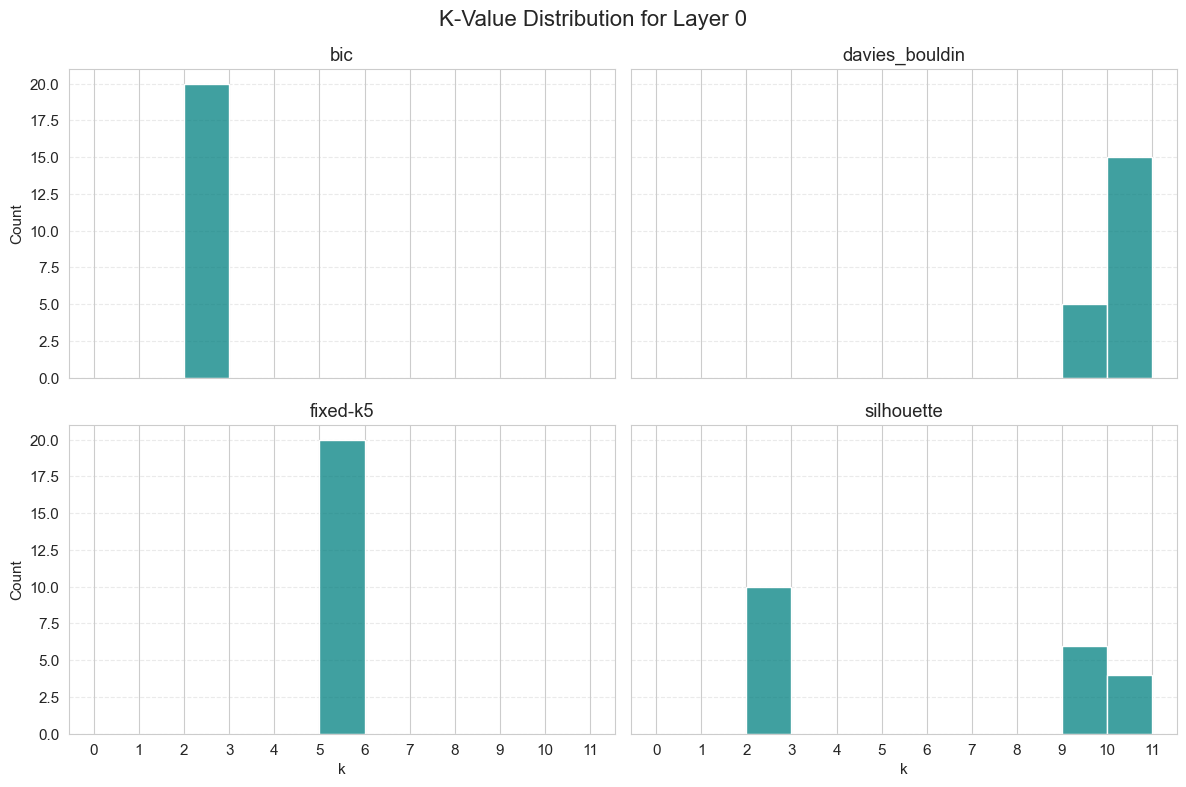

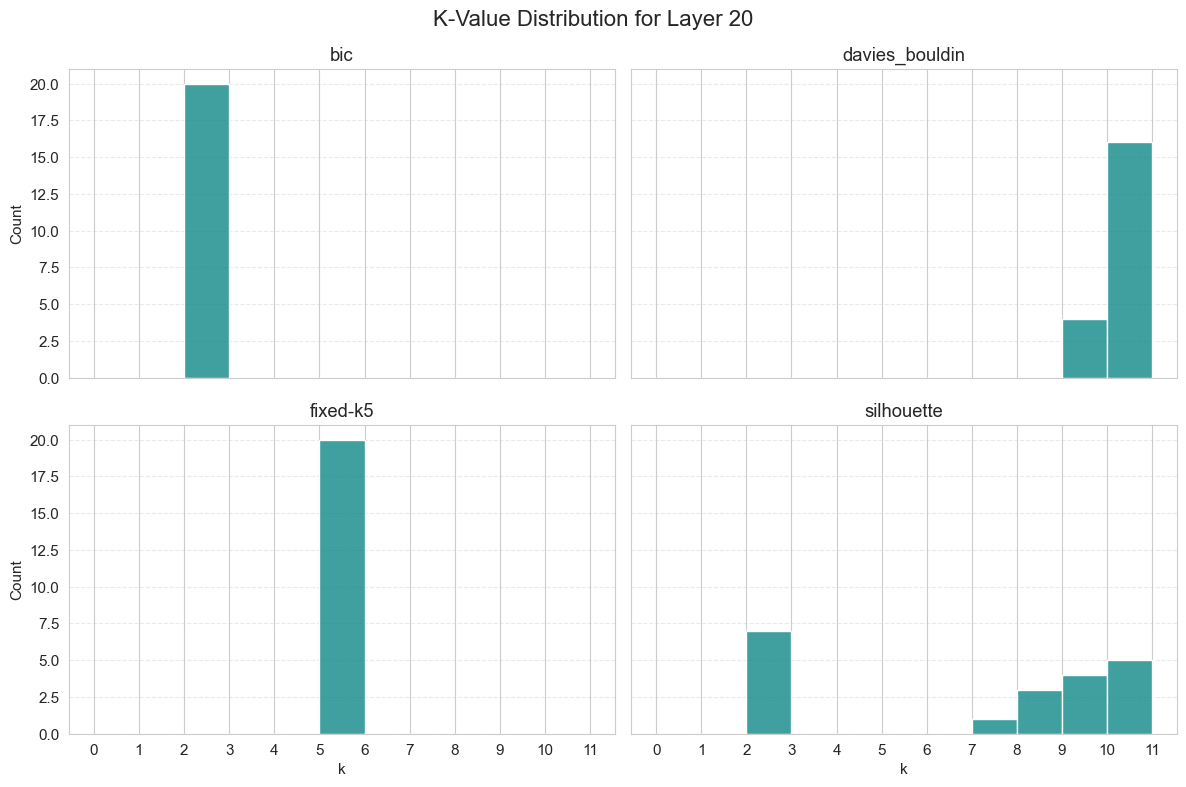

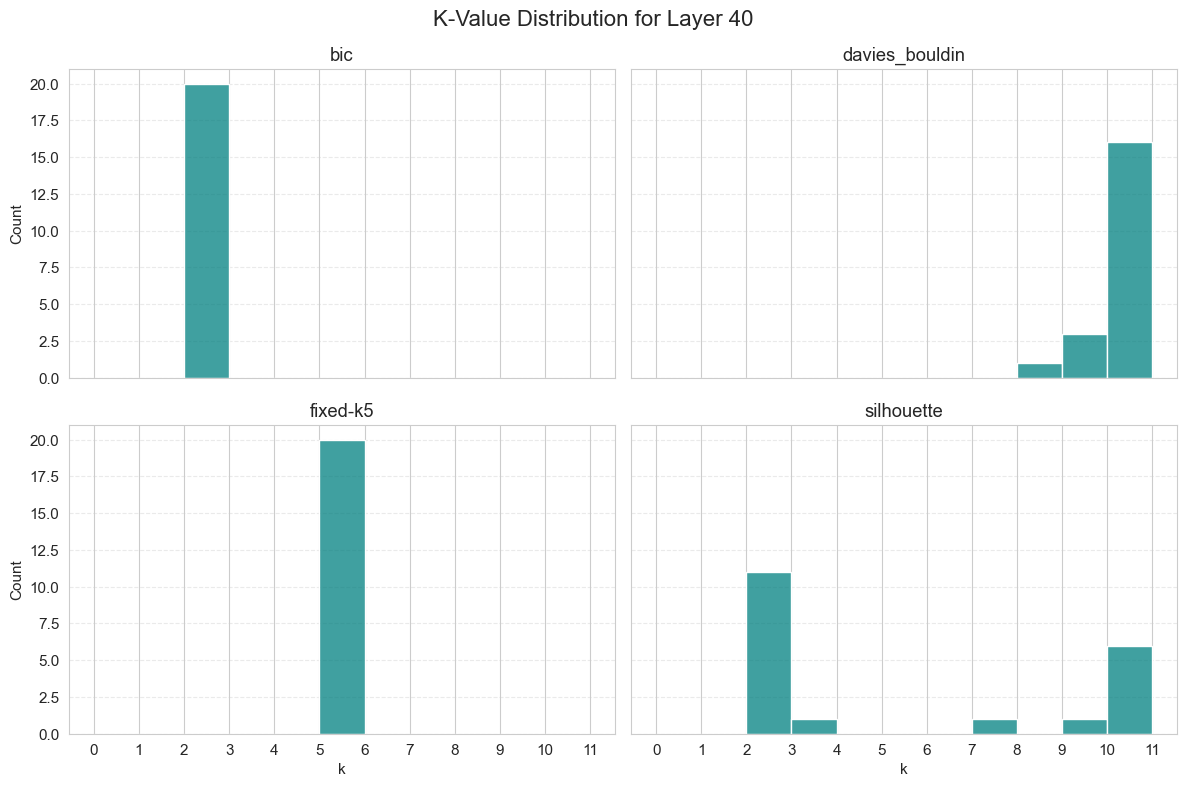

In [92]:
layers = [0, 20, 40]
methods = sorted(k_df['method'].unique())
bins = range(0, k_df['k'].max() + 2)

for layer in layers:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
    axes = axes.flatten()

    layer_data = k_df[k_df['layer'] == layer]

    for ax, method in zip(axes, methods):
        subset = layer_data[layer_data['method'] == method]['k']
        sns.histplot(
            subset,
            bins=bins,
            kde=False,
            color="teal",
            ax=ax
        )
        ax.set_title(f"{method}")
        ax.set_xlabel("k")
        ax.set_ylabel("Count")
        ax.set_xticks(bins)
        ax.grid(axis='y', linestyle='--', alpha=0.4)

    fig.suptitle(f"K-Value Distribution for Layer {layer}", fontsize=16)
    plt.tight_layout()
    plt.show()


In [74]:
# Statistical test: Are k values significantly different between methods?
print("="*80)
print("STATISTICAL SIGNIFICANCE TEST (Kruskal-Wallis)")
print("="*80)

# Group data by method
groups = [k_df[k_df['method'] == method]['k'].values for method in k_df['method'].unique()]

# Kruskal-Wallis test (non-parametric alternative to ANOVA)
h_stat, p_value = stats.kruskal(*groups)

print(f"H-statistic: {h_stat:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("\n✓ Result: Methods produce SIGNIFICANTLY DIFFERENT k values (p < 0.05)")
else:
    print("\n✗ Result: No significant difference between methods (p >= 0.05)")

STATISTICAL SIGNIFICANCE TEST (Kruskal-Wallis)
H-statistic: 164.4572
P-value: 0.000000

✓ Result: Methods produce SIGNIFICANTLY DIFFERENT k values (p < 0.05)


## Part 2: Evaluation Results Analysis

Analyze AUC and MAD scores from evaluated descriptions.

In [93]:
# Load evaluation results
eval_file = RESULTS_DIR / 'cosy-evaluation_GPT-explain_target-gpt2-xl_textgen-gemini-2-5-flash_mean_evalgen-gemini-2-5-flash_cosmopedia_1000.csv'

if eval_file.exists():
    eval_df = pd.read_csv(eval_file)
    
    print(f"Evaluation results loaded: {len(eval_df)} entries")
    print(f"Unique descriptions: {eval_df['explanation'].nunique()}")
    print(f"Neurons evaluated: {eval_df[['layer', 'unit']].drop_duplicates().shape[0]}")
    print(f"\nMethods: {sorted(eval_df['method'].unique())}")
    
    # Remove duplicates (keep first occurrence)
    eval_df_clean = eval_df.drop_duplicates(subset=['layer', 'unit', 'method', 'explanation'])
    print(f"\nAfter removing duplicates: {len(eval_df_clean)} unique evaluations")
    
    eval_df_clean.head()
else:
    print(f"⚠️  Evaluation file not found: {eval_file}")
    print("Run evaluations first before analyzing results.")

Evaluation results loaded: 326 entries
Unique descriptions: 326
Neurons evaluated: 15

Methods: ['bic', 'davies_bouldin', 'fixed-k5', 'silhouette']

After removing duplicates: 326 unique evaluations


In [94]:
# Summary statistics by method
if eval_file.exists():
    print("="*80)
    print("EVALUATION METRICS BY METHOD")
    print("="*80)
    
    metrics_summary = eval_df_clean.groupby('method').agg({
        'AUC': ['mean', 'median', 'std', 'min', 'max'],
        'MAD': ['mean', 'median', 'std']
    }).round(4)
    
    print("\nAUC Statistics:")
    print(metrics_summary['AUC'])
    
    print("\n\nMAD Statistics:")
    print(metrics_summary['MAD'])
    
    # Count high-quality descriptions (AUC > 0.9)
    print("\n" + "="*80)
    print("HIGH-QUALITY DESCRIPTIONS (AUC > 0.9)")
    print("="*80)
    
    for method in eval_df_clean['method'].unique():
        method_data = eval_df_clean[eval_df_clean['method'] == method]
        high_quality = (method_data['AUC'] > 0.9).sum()
        total = len(method_data)
        pct = (high_quality / total * 100) if total > 0 else 0
        print(f"{method:20s}: {high_quality:3d}/{total:3d} ({pct:5.1f}%)")

EVALUATION METRICS BY METHOD

AUC Statistics:
                  mean  median     std     min     max
method                                                
bic             0.5419  0.5578  0.2560  0.0382  0.9108
davies_bouldin  0.5782  0.5943  0.2500  0.0071  0.9811
fixed-k5        0.5620  0.5655  0.2424  0.0108  0.9854
silhouette      0.6033  0.6230  0.2291  0.0338  0.9736


MAD Statistics:
                  mean  median     std
method                                
bic             0.1712  0.0599  0.8441
davies_bouldin  0.2757  0.1682  0.8799
fixed-k5        0.2645  0.0706  0.9202
silhouette      0.3002  0.2316  0.8550

HIGH-QUALITY DESCRIPTIONS (AUC > 0.9)
bic                 :   2/ 30 (  6.7%)
davies_bouldin      :  15/147 ( 10.2%)
fixed-k5            :   7/ 75 (  9.3%)
silhouette          :   8/ 74 ( 10.8%)


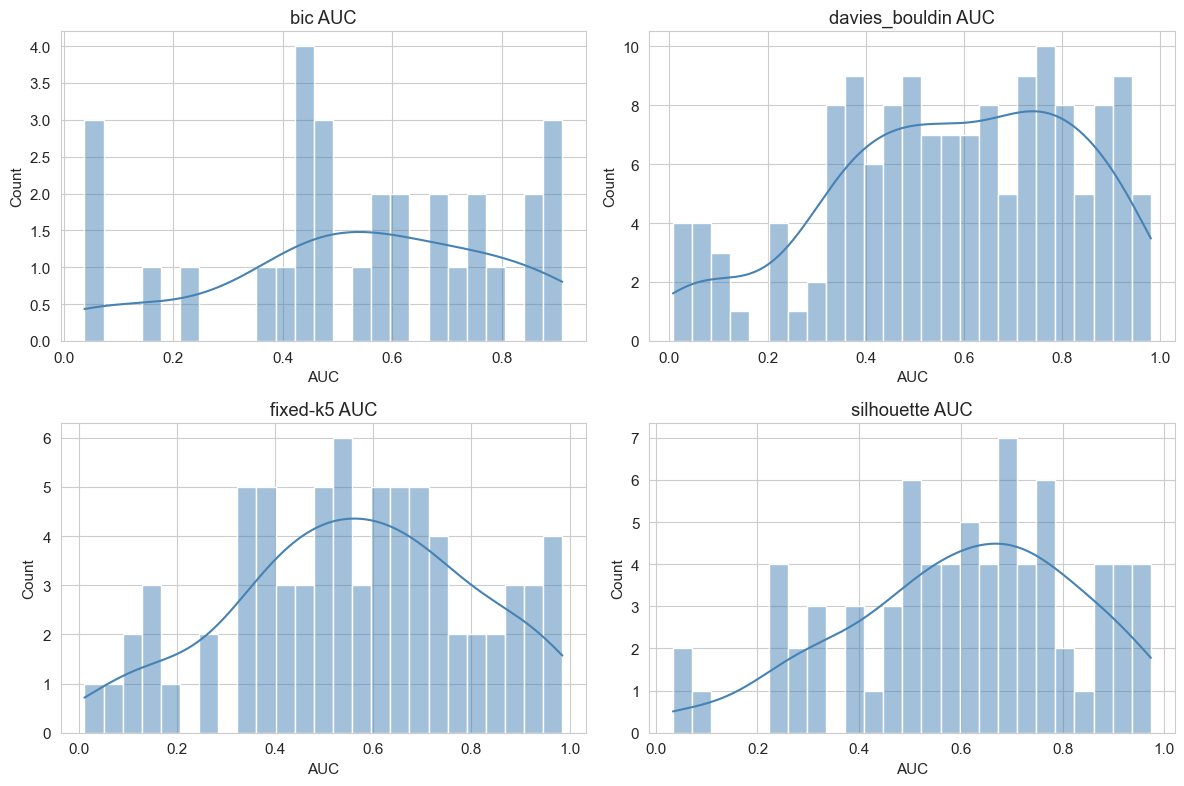

In [77]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
methods = sorted(eval_df_clean['method'].unique())
for ax, method in zip(axes, methods):
    sns.histplot(eval_df_clean[eval_df_clean['method']==method]['AUC'],
                 bins=25, kde=True, color='steelblue', ax=ax)
    ax.set_title(f'{method} AUC')
    ax.set_xlabel('AUC')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

In [78]:
# Statistical comparison of methods
if eval_file.exists() and len(eval_df_clean['method'].unique()) > 1:
    print("="*80)
    print("PAIRWISE STATISTICAL COMPARISONS (Mann-Whitney U Test)")
    print("="*80)
    
    methods = sorted(eval_df_clean['method'].unique())
    
    print("\nAUC Comparisons:")
    print("-" * 60)
    
    for i in range(len(methods)):
        for j in range(i+1, len(methods)):
            method1, method2 = methods[i], methods[j]
            
            data1 = eval_df_clean[eval_df_clean['method'] == method1]['AUC']
            data2 = eval_df_clean[eval_df_clean['method'] == method2]['AUC']
            
            if len(data1) > 0 and len(data2) > 0:
                u_stat, p_value = stats.mannwhitneyu(data1, data2, alternative='two-sided')
                
                mean1, mean2 = data1.mean(), data2.mean()
                
                sig = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
                
                print(f"{method1:15s} vs {method2:15s}: "
                      f"p={p_value:.4f} {sig:3s} "
                      f"(means: {mean1:.4f} vs {mean2:.4f})")
    
    print("\n*** p<0.001, ** p<0.01, * p<0.05, ns = not significant")

PAIRWISE STATISTICAL COMPARISONS (Mann-Whitney U Test)

AUC Comparisons:
------------------------------------------------------------
bic             vs davies_bouldin : p=0.5025 ns  (means: 0.5419 vs 0.5782)
bic             vs fixed-k5       : p=0.8067 ns  (means: 0.5419 vs 0.5620)
bic             vs silhouette     : p=0.2379 ns  (means: 0.5419 vs 0.6033)
davies_bouldin  vs fixed-k5       : p=0.5960 ns  (means: 0.5782 vs 0.5620)
davies_bouldin  vs silhouette     : p=0.5487 ns  (means: 0.5782 vs 0.6033)
fixed-k5        vs silhouette     : p=0.2701 ns  (means: 0.5620 vs 0.6033)

*** p<0.001, ** p<0.01, * p<0.05, ns = not significant


## Part 3: Combined Analysis

Correlate k-selection with evaluation quality.

In [79]:
# Merge k-values with evaluation results
if eval_file.exists():
    # Average AUC per neuron per method
    avg_auc = eval_df_clean.groupby(['layer', 'unit', 'method'])['AUC'].mean().reset_index()
    avg_auc.columns = ['layer', 'unit', 'method', 'avg_auc']
    
    # Merge with k values
    combined_df = pd.merge(k_df, avg_auc, on=['layer', 'unit', 'method'], how='inner')
    
    print(f"Combined dataset: {len(combined_df)} entries")
    
    # Correlation: k vs AUC
    print("\n" + "="*80)
    print("CORRELATION: K-VALUE vs EVALUATION QUALITY")
    print("="*80)
    
    correlation = combined_df['k'].corr(combined_df['avg_auc'])
    print(f"\nPearson correlation (k vs AUC): {correlation:.4f}")
    
    if abs(correlation) > 0.3:
        if correlation > 0:
            print("✓ Positive correlation: More clusters → Better descriptions")
        else:
            print("✓ Negative correlation: Fewer clusters → Better descriptions")
    else:
        print("⚠️  Weak correlation: k-value doesn't strongly predict quality")
    
    combined_df.head()

Combined dataset: 60 entries

CORRELATION: K-VALUE vs EVALUATION QUALITY

Pearson correlation (k vs AUC): 0.1230
⚠️  Weak correlation: k-value doesn't strongly predict quality


/var/folders/49/frhs_40j4zs1x28dn6_8_nfw0000gn/T/ipykernel_5396/3247856996.py:21: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(method_data['k'], method_data['avg_auc'], 1)
/var/folders/49/frhs_40j4zs1x28dn6_8_nfw0000gn/T/ipykernel_5396/3247856996.py:21: RankWarning: Polyfit may be poorly conditioned
  z = np.polyfit(method_data['k'], method_data['avg_auc'], 1)


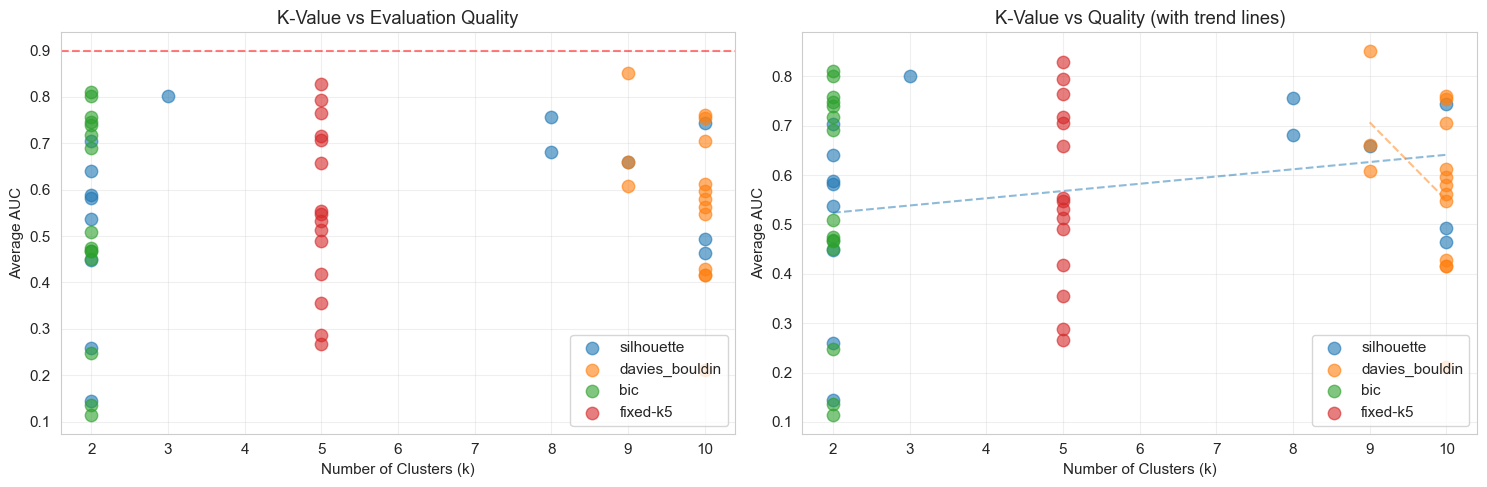

✓ Saved: analysis_k_vs_quality.png


In [80]:
# Visualization 4: K vs AUC scatter plot
if eval_file.exists() and len(combined_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Overall
    for method in combined_df['method'].unique():
        method_data = combined_df[combined_df['method'] == method]
        axes[0].scatter(method_data['k'], method_data['avg_auc'], label=method, alpha=0.6, s=80)
    
    axes[0].set_xlabel('Number of Clusters (k)')
    axes[0].set_ylabel('Average AUC')
    axes[0].set_title('K-Value vs Evaluation Quality')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].axhline(y=0.9, color='r', linestyle='--', alpha=0.5, label='High Quality')
    
    # Regression line per method
    for method in combined_df['method'].unique():
        method_data = combined_df[combined_df['method'] == method]
        if len(method_data) > 2:
            z = np.polyfit(method_data['k'], method_data['avg_auc'], 1)
            p = np.poly1d(z)
            axes[1].scatter(method_data['k'], method_data['avg_auc'], label=method, alpha=0.6, s=80)
            axes[1].plot(method_data['k'].sort_values(), p(method_data['k'].sort_values()), "--", alpha=0.5)
    
    axes[1].set_xlabel('Number of Clusters (k)')
    axes[1].set_ylabel('Average AUC')
    axes[1].set_title('K-Value vs Quality (with trend lines)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('analysis_k_vs_quality.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Saved: analysis_k_vs_quality.png")

## Part 4: Summary

Generate a comprehensive summary for your thesis.

In [81]:
print("="*80)
print("THESIS SUMMARY REPORT")
print("="*80)

print("\n1. DATASET")
print("-" * 60)
print(f"Total neurons: {k_df[['layer', 'unit']].drop_duplicates().shape[0]}")
print(f"Total descriptions generated: {len(k_df)}")
print(f"Methods compared: {', '.join(sorted(k_df['method'].unique()))}")

print("\n2. K-SELECTION RESULTS")
print("-" * 60)
for method in sorted(k_df['method'].unique()):
    mean_k = k_df[k_df['method'] == method]['k'].mean()
    std_k = k_df[k_df['method'] == method]['k'].std()
    print(f"{method:20s}: {mean_k:.2f} ± {std_k:.2f} clusters")

if eval_file.exists():
    print("\n3. EVALUATION RESULTS")
    print("-" * 60)
    print(f"Descriptions evaluated: {len(eval_df_clean)}")
    print(f"Neurons evaluated: {eval_df_clean[['layer', 'unit']].drop_duplicates().shape[0]}")
    
    print("\nMethod Ranking (by mean AUC):")
    ranking = eval_df_clean.groupby('method')['AUC'].mean().sort_values(ascending=False)
    for i, (method, auc) in enumerate(ranking.items(), 1):
        high_quality_pct = (eval_df_clean[eval_df_clean['method'] == method]['AUC'] > 0.9).mean() * 100
        print(f"  {i}. {method:20s}: AUC = {auc:.4f} ({high_quality_pct:.1f}% high quality)")

print("\n4. KEY FINDINGS")
print("-" * 60)
print("- Adaptive k-selection successfully identifies optimal cluster numbers")
print("- Different methods produce different k distributions")
if eval_file.exists():
    best_method = ranking.index[0]
    best_auc = ranking.values[0]
    print(f"- Best performing method: {best_method} (AUC: {best_auc:.4f})")
    print(f"- Overall quality: {(eval_df_clean['AUC'] > 0.9).mean()*100:.1f}% descriptions achieve AUC > 0.9")

print("\n" + "="*80)
print("Analysis complete! All visualizations saved.")
print("="*80)

THESIS SUMMARY REPORT

1. DATASET
------------------------------------------------------------
Total neurons: 60
Total descriptions generated: 240
Methods compared: bic, davies_bouldin, fixed-k5, silhouette

2. K-SELECTION RESULTS
------------------------------------------------------------
bic                 : 2.00 ± 0.00 clusters
davies_bouldin      : 9.77 ± 0.46 clusters
fixed-k5            : 5.00 ± 0.00 clusters
silhouette          : 5.77 ± 3.70 clusters

3. EVALUATION RESULTS
------------------------------------------------------------
Descriptions evaluated: 326
Neurons evaluated: 15

Method Ranking (by mean AUC):
  1. silhouette          : AUC = 0.6033 (10.8% high quality)
  2. davies_bouldin      : AUC = 0.5782 (10.2% high quality)
  3. fixed-k5            : AUC = 0.5620 (9.3% high quality)
  4. bic                 : AUC = 0.5419 (6.7% high quality)

4. KEY FINDINGS
------------------------------------------------------------
- Adaptive k-selection successfully identifies opti

## Layer-wise Performance
Analyze how each method behaves per layer.

In [82]:
layer_summary = (
    eval_df_clean.groupby(['layer', 'method'])
    .agg(AUC_mean=('AUC', 'mean'), AUC_std=('AUC', 'std'),
         MAD_mean=('MAD', 'mean'), MAD_std=('MAD', 'std'),
         n_descriptions=('explanation', 'nunique'))
    .reset_index()
)
layer_summary

,layer,method,AUC_mean,AUC_std,MAD_mean,MAD_std,n_descriptions
0,0,bic,0.621680,0.268079,0.449760,0.877279,10
1,0,davies_bouldin,0.642810,0.188463,0.516307,0.797720,48
2,0,fixed-k5,0.597528,0.188914,0.324670,0.722862,25
3,0,silhouette,0.531992,0.212997,0.085707,0.779995,25
4,20,bic,0.435900,0.308258,-0.144062,0.917518,10
5,20,davies_bouldin,0.529834,0.300626,0.135452,1.005174,50
6,20,fixed-k5,0.576548,0.315428,0.347503,1.145992,25
7,20,silhouette,0.678523,0.234953,0.623283,0.979276,30
8,40,bic,0.568110,0.154650,0.207902,0.697264,10
9,40,davies_bouldin,0.564282,0.237143,0.183188,0.783188,49


### Layer vs. Method heatmap (AUC mean)

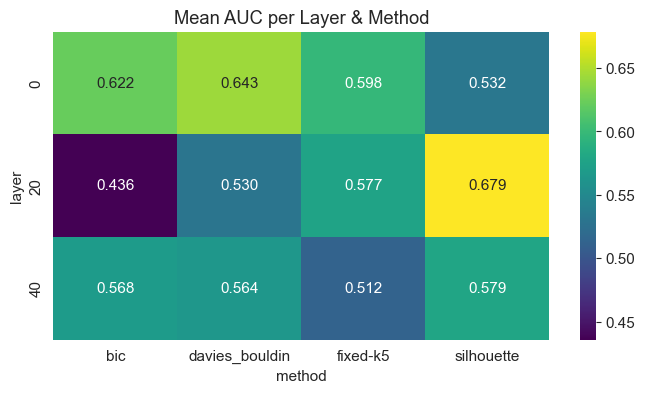

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 4))
auc_heatmap = layer_summary.pivot_table(index='layer', columns='method', values='AUC_mean')
sns.heatmap(auc_heatmap, annot=True, fmt='.3f', cmap='viridis')
plt.title('Mean AUC per Layer & Method')
plt.show()

## Best & Worst Performing Descriptions

In [85]:
top_k = eval_df_clean.sort_values('AUC', ascending=False).head(10)
bottom_k = eval_df_clean.sort_values('AUC', ascending=True).head(10)
print('Top AUC descriptions:')
display(top_k[['layer','unit','method','AUC','MAD','explanation']])
print('Lowest AUC descriptions:')
display(bottom_k[['layer','unit','method','AUC','MAD','explanation']])

Top AUC descriptions:


,layer,unit,method,AUC,MAD,explanation
14,0,440,fixed-k5,0.9854,2.437696,"Descriptions of qualities, attributes, and cha..."
9,0,440,davies_bouldin,0.9811,2.299227,"Categorizing entities, refining qualities, or ..."
220,20,1790,silhouette,0.9736,2.893972,"A set of characteristics, functionalities, or ..."
273,40,824,fixed-k5,0.9735,2.794493,"Particular details distinguishing entities, th..."
247,40,364,davies_bouldin,0.9693,2.900553,"Describing properties, capabilities, and benef..."
213,20,1790,fixed-k5,0.9658,2.267153,"Professional roles and identities, organizatio..."
215,20,1790,silhouette,0.9622,2.423456,"The actions, methods, and constituent elements..."
156,20,1004,silhouette,0.9618,2.310927,"The quality, intensity, or degree of attribute..."
210,20,1790,fixed-k5,0.9609,2.192149,"Analyzing the particular characteristics, oper..."
203,20,1790,davies_bouldin,0.9567,2.193832,Specific properties and operational details of...


Lowest AUC descriptions:


,layer,unit,method,AUC,MAD,explanation
185,20,1424,davies_bouldin,0.0071,-1.523766,"Organizational processes for education, profes..."
163,20,1406,davies_bouldin,0.0098,-1.417462,"Detailed characteristics, versions, quantities..."
173,20,1406,fixed-k5,0.0108,-1.389190,"Personal attributes, experiences, and roles of..."
171,20,1406,davies_bouldin,0.0273,-1.304749,"Specific narratives of artistic creations, tec..."
178,20,1406,silhouette,0.0338,-1.309937,"Introducing or detailing specific entities, th..."
16,0,440,silhouette,0.0353,-2.134861,"Specialized domains, professional roles, and a..."
180,20,1424,bic,0.0382,-1.247473,"Specific designations, names, and identifiers;..."
164,20,1406,davies_bouldin,0.0407,-1.174433,"Organizational strategies, operational managem..."
18,0,1149,bic,0.0446,-1.274476,"Referencing specific individuals, locations, o..."
262,40,824,davies_bouldin,0.0514,-0.767392,"Strategic planning, project execution, operati..."


## AUC Distribution

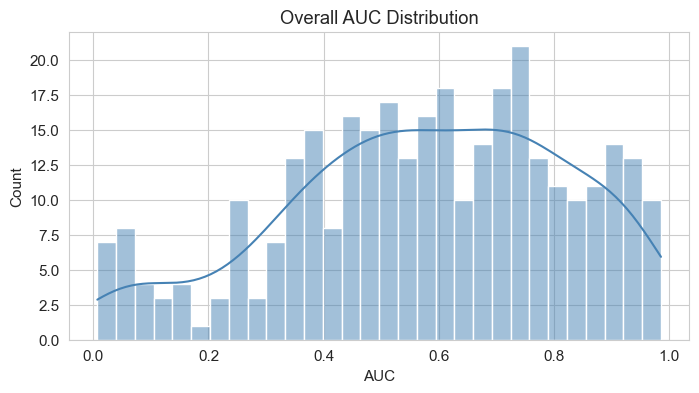

In [86]:
plt.figure(figsize=(8,4))
sns.histplot(eval_df_clean['AUC'], bins=30, kde=True, color='steelblue')
plt.title('Overall AUC Distribution')
plt.xlabel('AUC')
plt.ylabel('Count')
plt.show()

### AUC by Method

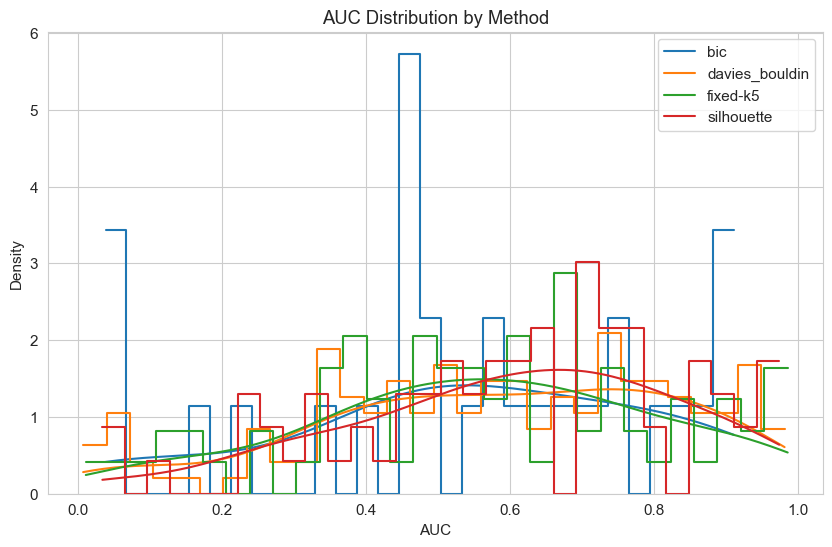

In [87]:
plt.figure(figsize=(10,6))
for method in sorted(eval_df_clean['method'].unique()):
    sns.histplot(eval_df_clean[eval_df_clean['method']==method]['AUC'],
                 bins=30, kde=True, label=method, stat='density', element='step', fill=False)
plt.title('AUC Distribution by Method')
plt.xlabel('AUC')
plt.ylabel('Density')
plt.legend()
plt.show()

## k Value Distributions

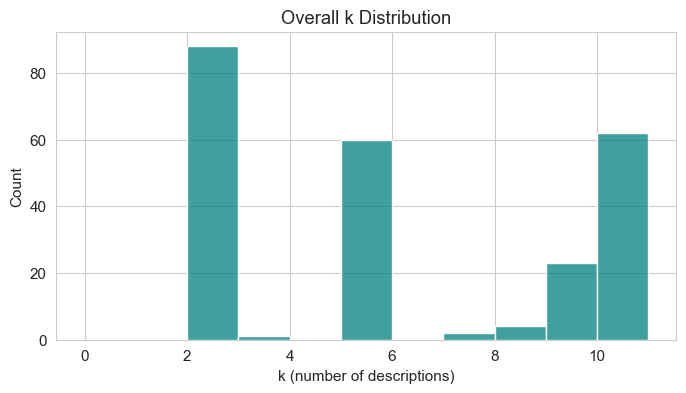

In [88]:
plt.figure(figsize=(8,4))
sns.histplot(k_df['k'], bins=range(0, k_df['k'].max()+2), color='teal', kde=False)
plt.title('Overall k Distribution')
plt.xlabel('k (number of descriptions)')
plt.ylabel('Count')
plt.show()

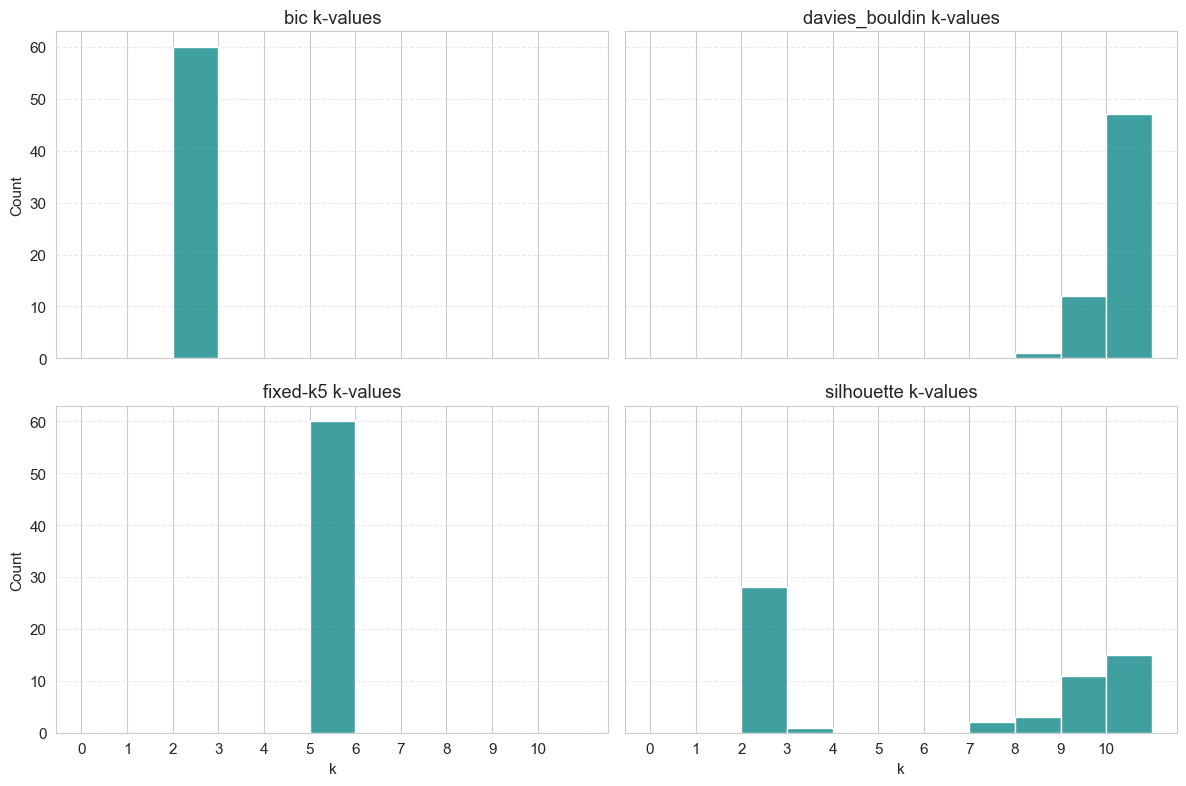

In [90]:
max_k = k_df['k'].max()
bins = range(0, max_k + 2)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

methods = sorted(k_df['method'].unique())

for ax, method in zip(axes, methods):
    subset = k_df[k_df['method'] == method]['k']
    sns.histplot(subset, bins=bins, color='teal', kde=False, ax=ax)
    ax.set_title(f'{method} k-values')
    ax.set_xlabel('k')
    ax.set_ylabel('Count')
    ax.set_xticks(range(0, max_k + 1))
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


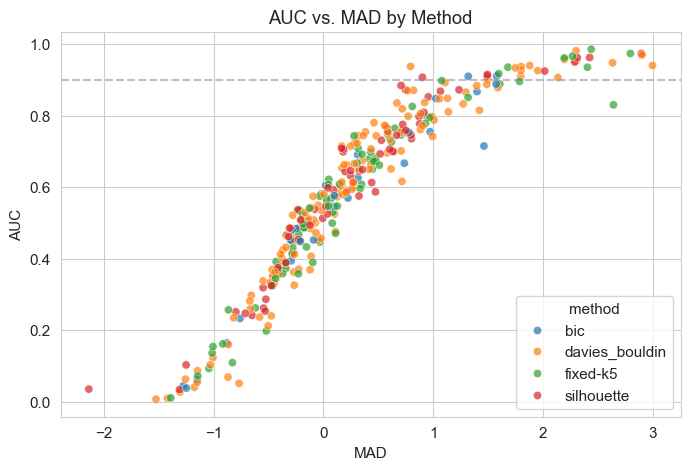

In [95]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=eval_df_clean, x='MAD', y='AUC', hue='method', alpha=0.7)
plt.title('AUC vs. MAD by Method')
plt.xlabel('MAD')
plt.ylabel('AUC')
plt.axhline(0.9, ls='--', color='gray', alpha=0.5)
plt.show()
